# 02 — Reducción de dimensionalidad: análisis individual, PCA y UMAP

Este notebook corresponde a la etapa posterior a la selección de modelos.

Según la comparación final por **ROC-AUC en validación**, los dos modelos usados en esta etapa son:

1. **MLP**: modelo final por la métrica oficial.
2. **Random Forest**: segundo mejor modelo por ROC-AUC en validación.

La idea no es repetir búsquedas de hiperparámetros costosas. Se reutilizan configuraciones finales ya seleccionadas y se evalúa cómo cambia el desempeño al reemplazar la representación original por representaciones reducidas con **PCA** y **UMAP**.

In [48]:
# Ejecuta esta celda solo si tu entorno no tiene umap-learn.
# En Kaggle/Colab normalmente funciona; en algunos entornos locales puede requerir internet.
try:
    import umap  # noqa: F401
    print("umap-learn ya está instalado.")
except ImportError:
    import sys
    !{sys.executable} -m pip install -q umap-learn
    print("umap-learn instalado. Si acabas de instalarlo, reinicia el kernel si aparece algún error de importación.")

2026-05-29 01:20:20.702018: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780017620.965735      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780017621.046408      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780017621.669165      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780017621.669227      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780017621.669232      58 computation_placer.cc:177] computation placer alr

umap-learn ya está instalado.


## 2. Importar librerías y configurar rutas

Las salidas de esta etapa se guardan dentro de `FinalStage/ReportAssets`, para no mezclarlas con artefactos globales del proyecto.

In [49]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
)
from scipy.stats import spearmanr
from umap import UMAP

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
TARGET_COLUMN = "cardiovascular_disease"

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "FinalStage" else CURRENT_DIR

REPORT_ASSETS_DIR = CURRENT_DIR / "ReportAssets" if CURRENT_DIR.name == "FinalStage" else PROJECT_ROOT / "FinalStage" / "ReportAssets"
FIGURES_DIR = REPORT_ASSETS_DIR / "figures"
TABLES_DIR = REPORT_ASSETS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("CURRENT_DIR:", CURRENT_DIR.resolve())
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("FIGURES_DIR:", FIGURES_DIR.resolve())
print("TABLES_DIR:", TABLES_DIR.resolve())

CURRENT_DIR: /kaggle/working
PROJECT_ROOT: /kaggle/working
FIGURES_DIR: /kaggle/working/FinalStage/ReportAssets/figures
TABLES_DIR: /kaggle/working/FinalStage/ReportAssets/tables


## 3. Cargar datos y reproducir el mismo split

Se usa el mismo dataset limpio y la misma partición **80% train, 10% validation, 10% test** con estratificación.

In [50]:
DATA_URL = "https://raw.githubusercontent.com/SantCorrea802/Cardiovascular_Disease_Proyecto_Modelos_II/main/dataset/data_cleaned.csv"

data = pd.read_csv(DATA_URL)

if "id" in data.columns:
    data = data.drop(columns=["id"])

if TARGET_COLUMN not in data.columns:
    raise ValueError(f"No existe la columna objetivo: {TARGET_COLUMN}")

features = data.drop(columns=[TARGET_COLUMN])
target = data[TARGET_COLUMN]

X_train, X_temp, y_train, y_temp = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Dataset:", data.shape)
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("\nDistribución train:")
print(y_train.value_counts(normalize=True).sort_index())

Dataset: (68589, 13)
X_train: (54871, 12)
X_val:   (6859, 12)
X_test:  (6859, 12)

Distribución train:
cardiovascular_disease
0    0.504966
1    0.495034
Name: proportion, dtype: float64


## 4. Definir tipos de variables y preprocesamiento

Para PCA y UMAP se requiere una representación numérica. Se usa un preprocesamiento común:

- variables numéricas: `StandardScaler`;
- variables nominales binarias/categóricas: `OneHotEncoder`;
- variables ordinales: `OrdinalEncoder` seguido de `StandardScaler`.

Esto evita fuga de información porque el preprocesador se ajusta únicamente con `X_train`.

In [51]:
nominal = [
    "gender",
    "smoke",
    "alcohol_intake",
    "physical_activity",
]

ordinal = [
    "cholesterol",
    "glucose",
    "bmi",
]

numerical = [
    "age",
    "height",
    "weight",
    "systolic_blood_pressure",
    "diastolic_blood_pressure",
]

expected_columns = set(nominal + ordinal + numerical)
missing_columns = expected_columns - set(X_train.columns)

if missing_columns:
    raise ValueError(f"Faltan columnas esperadas en el dataset: {missing_columns}")

ordinal_categories = [
    [1, 2, 3],              # cholesterol
    [1, 2, 3],              # glucose
    [0, 1, 2, 3, 4, 5],     # bmi
]

ordinal_pipeline = Pipeline(steps=[
    ("encoder", OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        encoded_missing_value=-2,
    )),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal),
        ("ord", ordinal_pipeline, ordinal),
    ],
    remainder="drop",
    sparse_threshold=0,
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Dimensión original cruda:", X_train.shape[1])
print("Dimensión después de preprocesamiento:", X_train_proc.shape[1])
print("Primeras variables transformadas:")
print(feature_names[:20])

Dimensión original cruda: 12
Dimensión después de preprocesamiento: 16
Primeras variables transformadas:
['num__age' 'num__height' 'num__weight' 'num__systolic_blood_pressure'
 'num__diastolic_blood_pressure' 'nom__gender_1' 'nom__gender_2'
 'nom__smoke_0' 'nom__smoke_1' 'nom__alcohol_intake_0'
 'nom__alcohol_intake_1' 'nom__physical_activity_0'
 'nom__physical_activity_1' 'ord__cholesterol' 'ord__glucose' 'ord__bmi']


## 5. Tabla oficial de modelos y selección top 2

Esta tabla es manual para evitar problemas de compatibilidad entre versiones de `scikit-learn` al cargar modelos `.joblib`.

La métrica oficial de selección es **ROC-AUC en validación**. Las demás métricas ayudan a interpretar el comportamiento operativo.

In [52]:
model_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc_val": 0.7966,
        "roc_auc_test": 0.7925,
        "accuracy_test": 0.7317,
        "precision_test": 0.7656,
        "recall_test": 0.6601,
        "f1_test": 0.7090,
        "f2_test": 0.686191,
        "FN_test": 1127,
        "FP_test": 678,
    },
    {
        "model": "KNN",
        "roc_auc_val": 0.799542,
        "roc_auc_test": 0.798452,
        "accuracy_test": 0.579822,
        "precision_test": 0.542488,
        "recall_test": 0.964654,
        "f1_test": 0.694444,
        "f2_test": 0.834735,
        "FN_test": 120,
        "FP_test": 2762,
    },
    {
        "model": "Random Forest",
        "roc_auc_val": 0.8065,
        "roc_auc_test": 0.8036,
        "accuracy_test": 0.7368,
        "precision_test": 0.7699,
        "recall_test": 0.6680,
        "f1_test": 0.7153,
        "f2_test": 0.686191,
        "FN_test": 1127,
        "FP_test": 678,
    },
    {
        "model": "SVM",
        "roc_auc_val": 0.800442,
        "roc_auc_test": 0.795748,
        "accuracy_test": 0.539146,
        "precision_test": 0.518190,
        "recall_test": 0.981738,
        "f1_test": 0.678335,
        "f2_test": 0.832750,
        "FN_test": 62,
        "FP_test": 3099,
    },
    {
        "model": "MLP",
        "roc_auc_val": 0.806683,
        "roc_auc_test": 0.804413,
        "accuracy_test": 0.599650,
        "precision_test": 0.555385,
        "recall_test": 0.958468,
        "f1_test": 0.703263,
        "f2_test": 0.836977,
        "FN_test": 141,
        "FP_test": 2605,
    },
])

model_results_sorted = model_results.sort_values(
    by=["roc_auc_val", "roc_auc_test", "f2_test"],
    ascending=[False, False, False],
).reset_index(drop=True)

model_results_sorted.to_csv(TABLES_DIR / "model_comparison_final.csv", index=False)
model_results_sorted.to_latex(TABLES_DIR / "model_comparison_final.tex", index=False, float_format="%.4f")

final_model = model_results_sorted.iloc[0]
top2_models = model_results_sorted.head(2).copy()

print("Modelo final por ROC-AUC validation:", final_model["model"])
print("Top 2 para PCA/UMAP:")
display(top2_models[["model", "roc_auc_val", "roc_auc_test", "f2_test"]])
model_results_sorted

Modelo final por ROC-AUC validation: MLP
Top 2 para PCA/UMAP:


,model,roc_auc_val,roc_auc_test,f2_test
0,MLP,0.806683,0.804413,0.836977
1,Random Forest,0.806500,0.803600,0.686191


,model,roc_auc_val,roc_auc_test,accuracy_test,precision_test,recall_test,f1_test,f2_test,FN_test,FP_test
0,MLP,0.806683,0.804413,0.599650,0.555385,0.958468,0.703263,0.836977,141,2605
1,Random Forest,0.806500,0.803600,0.736800,0.769900,0.668000,0.715300,0.686191,1127,678
2,SVM,0.800442,0.795748,0.539146,0.518190,0.981738,0.678335,0.832750,62,3099
3,KNN,0.799542,0.798452,0.579822,0.542488,0.964654,0.694444,0.834735,120,2762
4,Logistic Regression,0.796600,0.792500,0.731700,0.765600,0.660100,0.709000,0.686191,1127,678


## 6. Análisis individual de variables

Antes de aplicar PCA/UMAP, se calcula una medida individual de asociación entre cada variable y la clase:

- **Mutual Information**: dependencia estadística no necesariamente lineal.
- **Spearman absoluto**: asociación monótona entre variable y target.

Esto no reemplaza la selección multivariada de modelos, pero ayuda a documentar qué variables tienen mayor señal individual.

In [53]:
mi_values = mutual_info_classif(
    X_train,
    y_train,
    discrete_features="auto",
    random_state=RANDOM_STATE,
)

spearman_abs = []
for col in X_train.columns:
    corr, _ = spearmanr(X_train[col], y_train)
    spearman_abs.append(abs(corr) if not np.isnan(corr) else 0.0)

feature_analysis = pd.DataFrame({
    "feature": X_train.columns,
    "mutual_information": mi_values,
    "abs_spearman_corr": spearman_abs,
}).sort_values("mutual_information", ascending=False).reset_index(drop=True)

feature_analysis.to_csv(TABLES_DIR / "individual_feature_analysis.csv", index=False)
feature_analysis.to_latex(TABLES_DIR / "individual_feature_analysis.tex", index=False, float_format="%.4f")

feature_analysis

,feature,mutual_information,abs_spearman_corr
0,systolic_blood_pressure,0.117890,0.449492
1,diastolic_blood_pressure,0.075053,0.357063
2,age,0.030376,0.235524
3,cholesterol,0.029889,0.212988
4,bmi,0.020669,0.185776
5,weight,0.011239,0.179947
6,physical_activity,0.009770,0.033393
7,glucose,0.007245,0.089205
8,gender,0.006509,0.008593
9,alcohol_intake,0.001656,0.009087


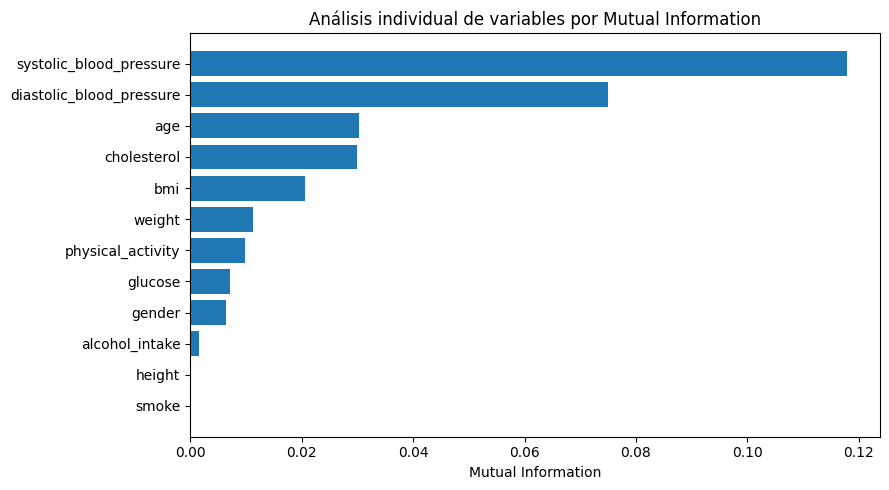

In [54]:
plt.figure(figsize=(9, 5))
plot_df = feature_analysis.sort_values("mutual_information", ascending=True)
plt.barh(plot_df["feature"], plot_df["mutual_information"])
plt.xlabel("Mutual Information")
plt.title("Análisis individual de variables por Mutual Information")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_mutual_information.png", dpi=300, bbox_inches="tight")
plt.show()

La gráfica dice que las variables con mayor relación individual con la enfermedad cardiovascular son:

- systolic_blood_pressure
- diastolic_blood_pressure
- age
- cholesterol
- bmi

Variables como:

- smoke
- height
- alcohol_intake
- gender

aportan muy poca información individualmente.

## 7. PCA: reducción lineal de dimensionalidad

PCA busca componentes ortogonales que maximizan varianza explicada. Se ajusta solo en `train` y luego se aplica a validation/test.

Criterio usado: seleccionar el menor número de componentes que explique al menos el **95%** de la varianza acumulada.

Dimensión preprocesada: 16
Componentes PCA seleccionados: 9
Varianza acumulada: 0.9699315997169279


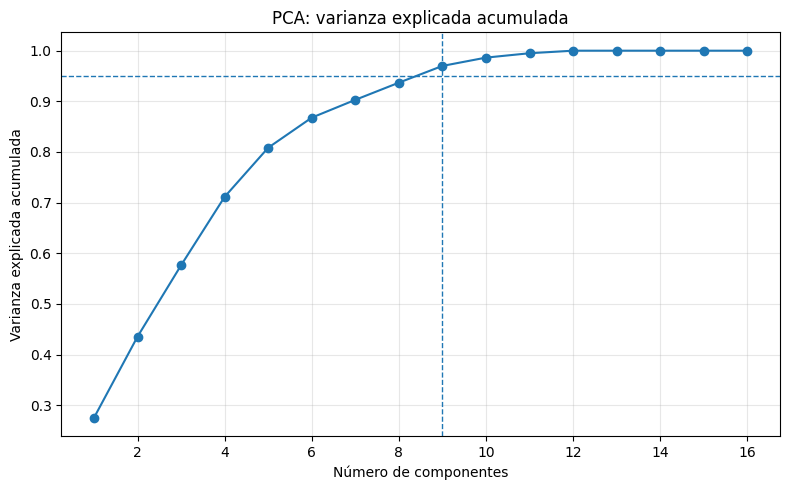

In [55]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_proc)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
PCA_VARIANCE_THRESHOLD = 0.95
n_components_95 = int(np.searchsorted(cumulative_variance, PCA_VARIANCE_THRESHOLD) + 1)

# Garantía: debe reducir respecto a la dimensión preprocesada.
if n_components_95 >= X_train_proc.shape[1]:
    n_components_95 = X_train_proc.shape[1] - 1

print("Dimensión preprocesada:", X_train_proc.shape[1])
print("Componentes PCA seleccionados:", n_components_95)
print("Varianza acumulada:", cumulative_variance[n_components_95 - 1])

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(PCA_VARIANCE_THRESHOLD, linestyle="--", linewidth=1)
plt.axvline(n_components_95, linestyle="--", linewidth=1)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA: varianza explicada acumulada")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_proc)
X_val_pca = pca.transform(X_val_proc)
X_test_pca = pca.transform(X_test_proc)

pca_reduction_pct = 100 * (1 - X_train_pca.shape[1] / X_train_proc.shape[1])

print("X_train_pca:", X_train_pca.shape)
print(f"Reducción PCA respecto a dimensión preprocesada: {pca_reduction_pct:.2f}%")

X_train_pca: (54871, 9)
Reducción PCA respecto a dimensión preprocesada: 43.75%


PCA seleccionó:

9 componentes de 16 variables preprocesadas

con:

- 96.99% de varianza acumulada
- 43.75% de reducción dimensional

Eso está bien. PCA logró reducir dimensión sin destruir casi nada de información relevante.

Comparando resultados:

| Representación | Modelo | ROC-AUC test | F2 test |  FN |   FP |
| -------------- | -----: | -----------: | ------: | --: | ---: |
| Original       |    MLP |       0.8044 |  0.8372 | 138 | 2615 |
| PCA            |    MLP |       0.8026 |  0.8381 |  94 | 2813 |
| Original       |     RF |       0.8036 |  0.8341 | 147 | 2641 |
| PCA            |     RF |       0.8003 |  0.8351 | 142 | 2643 |


Conclusión: PCA es aceptable, porque baja de 16 a 9 componentes y mantiene casi igual el ROC-AUC. Incluso en MLP sube un poco F2 y baja FN, aunque aumenta FP.

## 8. UMAP: reducción no lineal de dimensionalidad

UMAP construye una representación de baja dimensión intentando preservar estructura local del espacio de datos.

Aquí se usa `n_components=2` porque permite visualización directa y representa una reducción fuerte. Esto puede degradar desempeño predictivo; justamente eso se evalúa en la siguiente sección.

In [57]:
UMAP_COMPONENTS = 2

umap_reducer = UMAP(
    n_components=UMAP_COMPONENTS,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

X_train_umap = umap_reducer.fit_transform(X_train_proc)
X_val_umap = umap_reducer.transform(X_val_proc)
X_test_umap = umap_reducer.transform(X_test_proc)

umap_reduction_pct = 100 * (1 - X_train_umap.shape[1] / X_train_proc.shape[1])

print("X_train_umap:", X_train_umap.shape)
print(f"Reducción UMAP respecto a dimensión preprocesada: {umap_reduction_pct:.2f}%")

X_train_umap: (54871, 2)
Reducción UMAP respecto a dimensión preprocesada: 87.50%


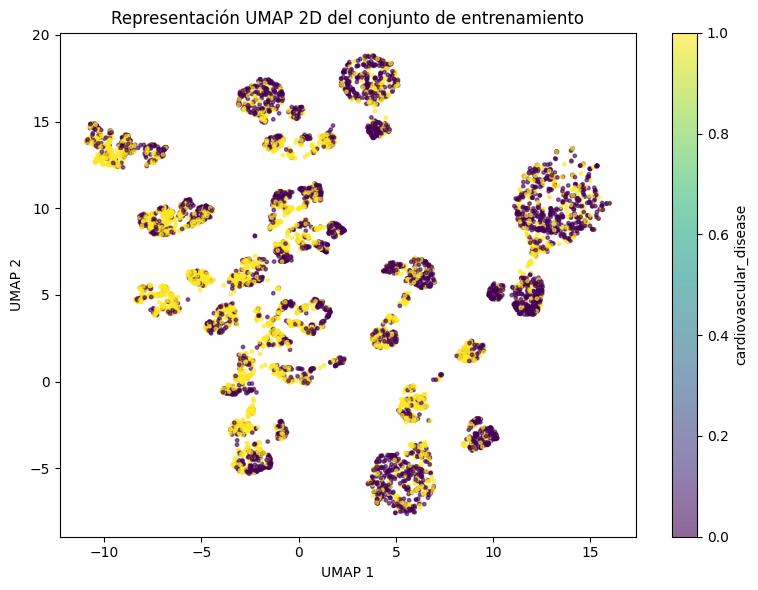

In [58]:
# Visualización UMAP sobre una muestra para que el gráfico no sea demasiado pesado.
plot_sample_size = min(8000, len(X_train_umap))
rng = np.random.default_rng(RANDOM_STATE)
plot_idx = rng.choice(len(X_train_umap), size=plot_sample_size, replace=False)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_umap[plot_idx, 0],
    X_train_umap[plot_idx, 1],
    c=y_train.iloc[plot_idx],
    s=6,
    alpha=0.6,
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Representación UMAP 2D del conjunto de entrenamiento")
plt.colorbar(scatter, label="cardiovascular_disease")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "umap_embedding_train.png", dpi=300, bbox_inches="tight")
plt.show()

La gráfica UMAP muestra muchos grupos mezclados entre clase 0 y clase 1. Eso indica que UMAP no separó limpiamente las clases en 2D.

Conclusión: UMAP no conviene como representación final para predicción, aunque sirve para visualizar estructura local de los datos.

## 9. Definir modelos top 2 con hiperparámetros fijos

No se repite `RandomizedSearchCV`. Se usan configuraciones finales ya seleccionadas:

- **MLP**: configuración `tanh`, `(64, 32)`, regularizada.
- **Random Forest**: configuración optimizada del notebook de Random Forest.

Si en el notebook original se actualizan hiperparámetros finales, solo se debe modificar esta celda.

In [59]:
def build_mlp_model():
    return MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="tanh",
        solver="adam",
        alpha=1e-3,
        learning_rate_init=1e-3,
        batch_size=64,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=25,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )


def build_random_forest_model():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=1,
        max_features="log2",
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

MODEL_BUILDERS = {
    "MLP": build_mlp_model,
    "Random Forest": build_random_forest_model,
}

REPRESENTATIONS = {
    "Original preprocessed": {
        "X_train": X_train_proc,
        "X_val": X_val_proc,
        "X_test": X_test_proc,
        "components": X_train_proc.shape[1],
        "reduction_pct": 0.0,
    },
    "PCA": {
        "X_train": X_train_pca,
        "X_val": X_val_pca,
        "X_test": X_test_pca,
        "components": X_train_pca.shape[1],
        "reduction_pct": pca_reduction_pct,
    },
    "UMAP": {
        "X_train": X_train_umap,
        "X_val": X_val_umap,
        "X_test": X_test_umap,
        "components": X_train_umap.shape[1],
        "reduction_pct": umap_reduction_pct,
    },
}

## 10. Funciones de evaluación

Para cada representación se entrena el modelo en `train`, se calcula ROC-AUC en validation/test y se ajusta el threshold en validation maximizando F2. Ese threshold se aplica una sola vez en test.

In [60]:
def get_scores_from_model(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    raise AttributeError("El modelo no expone predict_proba ni decision_function.")


def metrics_from_threshold(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }


def find_best_threshold_by_f2(y_true, y_score, n_thresholds=200):
    thresholds = np.linspace(float(np.min(y_score)), float(np.max(y_score)), n_thresholds)
    rows = []
    for threshold in thresholds:
        row = metrics_from_threshold(y_true, y_score, threshold)
        row["threshold"] = threshold
        rows.append(row)
    threshold_df = pd.DataFrame(rows)
    threshold_df = threshold_df.sort_values(
        by=["f2", "FN", "recall"],
        ascending=[False, True, False],
    ).reset_index(drop=True)
    return float(threshold_df.iloc[0]["threshold"]), threshold_df

## 11. Entrenar y evaluar MLP / Random Forest con representación original, PCA y UMAP

Esta celda puede tardar algunos minutos, especialmente por el MLP. No hace búsqueda de hiperparámetros.

In [61]:
results = []
roc_curves = {}
threshold_tables = {}
trained_models = {}

for representation_name, rep in REPRESENTATIONS.items():
    print(f"\n=== Representación: {representation_name} ===")

    for model_name, builder in MODEL_BUILDERS.items():
        print(f"Entrenando {model_name}...")
        model = builder()

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            model.fit(rep["X_train"], y_train)

        val_score = get_scores_from_model(model, rep["X_val"])
        test_score = get_scores_from_model(model, rep["X_test"])

        best_threshold, threshold_df = find_best_threshold_by_f2(y_val, val_score)

        val_metrics = metrics_from_threshold(y_val, val_score, best_threshold)
        test_metrics = metrics_from_threshold(y_test, test_score, best_threshold)

        row = {
            "representation": representation_name,
            "model": model_name,
            "components": rep["components"],
            "reduction_pct": rep["reduction_pct"],
            "threshold": best_threshold,
            "roc_auc_val": val_metrics["roc_auc"],
            "roc_auc_test": test_metrics["roc_auc"],
            "accuracy_test": test_metrics["accuracy"],
            "precision_test": test_metrics["precision"],
            "recall_test": test_metrics["recall"],
            "f1_test": test_metrics["f1"],
            "f2_test": test_metrics["f2"],
            "FN_test": test_metrics["FN"],
            "FP_test": test_metrics["FP"],
        }
        results.append(row)

        fpr, tpr, _ = roc_curve(y_test, test_score)
        roc_curves[(representation_name, model_name)] = (fpr, tpr, test_metrics["roc_auc"])
        threshold_tables[(representation_name, model_name)] = threshold_df
        trained_models[(representation_name, model_name)] = model

        print(
            f"{model_name} | AUC val={row['roc_auc_val']:.4f} | "
            f"AUC test={row['roc_auc_test']:.4f} | F2 test={row['f2_test']:.4f} | "
            f"threshold={best_threshold:.4f}"
        )

dimred_results = pd.DataFrame(results).sort_values(
    by=["roc_auc_val", "roc_auc_test", "f2_test"],
    ascending=[False, False, False],
).reset_index(drop=True)

dimred_results.to_csv(TABLES_DIR / "dimensionality_reduction_results.csv", index=False)
dimred_results.to_latex(TABLES_DIR / "dimensionality_reduction_results.tex", index=False, float_format="%.4f")

dimred_results


=== Representación: Original preprocessed ===
Entrenando MLP...
MLP | AUC val=0.8067 | AUC test=0.8044 | F2 test=0.8372 | threshold=0.2081
Entrenando Random Forest...
Random Forest | AUC val=0.8064 | AUC test=0.8036 | F2 test=0.8341 | threshold=0.2253

=== Representación: PCA ===
Entrenando MLP...
MLP | AUC val=0.8054 | AUC test=0.8026 | F2 test=0.8381 | threshold=0.1725
Entrenando Random Forest...
Random Forest | AUC val=0.8017 | AUC test=0.8003 | F2 test=0.8351 | threshold=0.2161

=== Representación: UMAP ===
Entrenando MLP...
MLP | AUC val=0.7519 | AUC test=0.7546 | F2 test=0.8331 | threshold=0.1896
Entrenando Random Forest...
Random Forest | AUC val=0.7704 | AUC test=0.7689 | F2 test=0.8332 | threshold=0.1779


,representation,model,components,reduction_pct,threshold,roc_auc_val,roc_auc_test,accuracy_test,precision_test,recall_test,f1_test,f2_test,FN_test,FP_test
0,Original preprocessed,MLP,16,0.00,0.208132,0.806683,0.804413,0.598630,0.554666,0.959352,0.702924,0.837189,138,2615
1,Original preprocessed,Random Forest,16,0.00,0.225343,0.806391,0.803601,0.593527,0.551537,0.956701,0.699698,0.834147,147,2641
2,PCA,MLP,9,43.75,0.172498,0.805390,0.802600,0.576177,0.539908,0.972312,0.694290,0.838073,94,2813
3,PCA,Random Forest,9,43.75,0.216058,0.801685,0.800269,0.593964,0.551730,0.958174,0.700248,0.835130,142,2643
4,UMAP,Random Forest,2,87.50,0.177895,0.770442,0.768882,0.543665,0.520732,0.980265,0.680155,0.833208,67,3063
5,UMAP,MLP,2,87.50,0.189628,0.751856,0.754565,0.540312,0.518836,0.981738,0.678888,0.833083,62,3091


## 12. Curvas ROC en test para las representaciones evaluadas

Esta figura permite comparar si PCA/UMAP conserva o degrada la capacidad discriminativa de los modelos top 2.

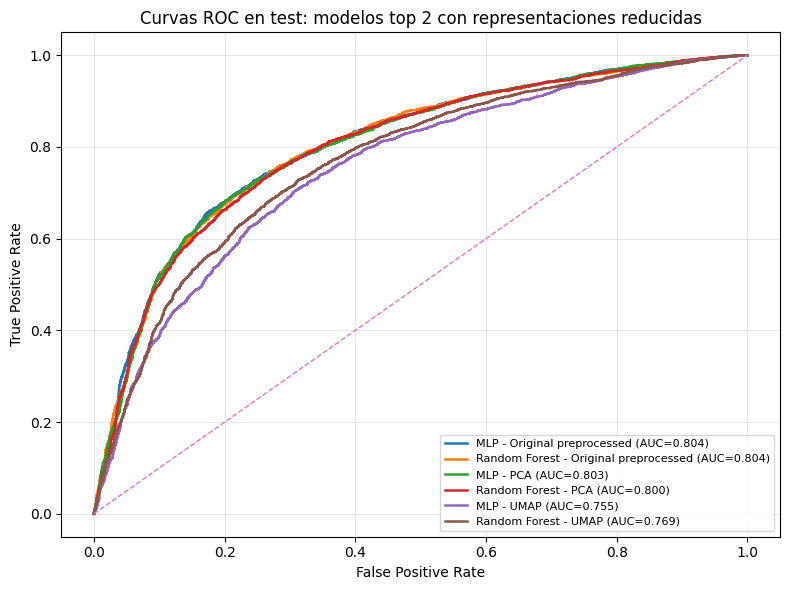

In [62]:
plt.figure(figsize=(8, 6))

for (representation_name, model_name), (fpr, tpr, auc_value) in roc_curves.items():
    label = f"{model_name} - {representation_name} (AUC={auc_value:.3f})"
    plt.plot(fpr, tpr, linewidth=1.8, label=label)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC en test: modelos top 2 con representaciones reducidas")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dimred_roc_curves_test.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Resumen para el informe

La siguiente tabla es la versión compacta que puede llevarse al informe. Si el espacio es limitado, reporta principalmente `ROC-AUC Test`, `F2 Test`, número de componentes y porcentaje de reducción.

In [63]:
report_table = dimred_results[[
    "representation",
    "model",
    "components",
    "reduction_pct",
    "roc_auc_val",
    "roc_auc_test",
    "f2_test",
    "FN_test",
    "FP_test",
]].copy()

report_table["reduction_pct"] = report_table["reduction_pct"].round(2)

report_table.to_csv(TABLES_DIR / "dimred_report_table.csv", index=False)
report_table.to_latex(TABLES_DIR / "dimred_report_table.tex", index=False, float_format="%.4f")

report_table

,representation,model,components,reduction_pct,roc_auc_val,roc_auc_test,f2_test,FN_test,FP_test
0,Original preprocessed,MLP,16,0.00,0.806683,0.804413,0.837189,138,2615
1,Original preprocessed,Random Forest,16,0.00,0.806391,0.803601,0.834147,147,2641
2,PCA,MLP,9,43.75,0.805390,0.802600,0.838073,94,2813
3,PCA,Random Forest,9,43.75,0.801685,0.800269,0.835130,142,2643
4,UMAP,Random Forest,2,87.50,0.770442,0.768882,0.833208,67,3063
5,UMAP,MLP,2,87.50,0.751856,0.754565,0.833083,62,3091


In [64]:
summary = {
    "official_final_model": str(final_model["model"]),
    "top2_models_for_dimensionality_reduction": top2_models["model"].tolist(),
    "preprocessed_dimension": int(X_train_proc.shape[1]),
    "pca_components": int(X_train_pca.shape[1]),
    "pca_reduction_pct": float(pca_reduction_pct),
    "umap_components": int(X_train_umap.shape[1]),
    "umap_reduction_pct": float(umap_reduction_pct),
    "best_dimensionality_reduction_result": dimred_results.iloc[0].to_dict(),
}

with open(TABLES_DIR / "dimensionality_reduction_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

summary

{'official_final_model': 'MLP',
 'top2_models_for_dimensionality_reduction': ['MLP', 'Random Forest'],
 'preprocessed_dimension': 16,
 'pca_components': 9,
 'pca_reduction_pct': 43.75,
 'umap_components': 2,
 'umap_reduction_pct': 87.5,
 'best_dimensionality_reduction_result': {'representation': 'Original preprocessed',
  'model': 'MLP',
  'components': 16,
  'reduction_pct': 0.0,
  'threshold': 0.20813215256804957,
  'roc_auc_val': 0.806683229101724,
  'roc_auc_test': 0.8044130751988897,
  'accuracy_test': 0.5986295378335035,
  'precision_test': 0.5546662125340599,
  'recall_test': 0.9593519882179676,
  'f1_test': 0.7029243552390202,
  'f2_test': 0.8371889779971211,
  'FN_test': 138,
  'FP_test': 2615}}

## 14. Conclusiones de la etapa de reducción de dimensionalidad

El análisis individual de variables mostró que las variables con mayor información respecto a la enfermedad cardiovascular fueron principalmente `systolic_blood_pressure`, `diastolic_blood_pressure`, `age`, `cholesterol` y `bmi`. Esto es coherente con el contexto clínico del problema, ya que la presión arterial, la edad, el colesterol y el índice de masa corporal están directamente relacionados con riesgo cardiovascular. Variables como `smoke`, `height`, `alcohol_intake` y `gender` presentaron menor contribución individual según Mutual Information. Sin embargo, estas variables no deben eliminarse automáticamente, porque este análisis es univariado y no captura posibles interacciones entre variables.

En PCA, la representación original preprocesada tenía 16 dimensiones. Usando el criterio de preservar al menos el 95% de la varianza explicada, se seleccionaron 9 componentes principales, alcanzando una varianza acumulada aproximada de 96.99%. Esto representa una reducción dimensional del 43.75%. Al evaluar nuevamente los dos mejores modelos, MLP y Random Forest, PCA mantuvo un rendimiento muy cercano al de la representación original. En particular, MLP con PCA obtuvo un ROC-AUC de test de 0.8026 frente a 0.8044 con la representación original, una pérdida muy pequeña. Además, su F2-score fue ligeramente mayor y redujo los falsos negativos, aunque aumentó los falsos positivos.

UMAP redujo la representación a 2 dimensiones, logrando una reducción dimensional del 87.5%. Sin embargo, esta reducción fue mucho más agresiva y produjo una caída clara en ROC-AUC. MLP con UMAP obtuvo un ROC-AUC de test de 0.7546 y Random Forest con UMAP obtuvo 0.7689, valores inferiores a los obtenidos con la representación original y con PCA. La visualización 2D de UMAP también mostró una mezcla importante entre las clases, sin una separación clara entre pacientes con y sin enfermedad cardiovascular.

En consecuencia, la representación original preprocesada sigue siendo la mejor opción si el criterio principal es maximizar ROC-AUC. No obstante, PCA es una alternativa razonable si se desea reducir dimensionalidad manteniendo casi el mismo desempeño predictivo. UMAP, en cambio, resulta útil como herramienta exploratoria de visualización, pero no como representación final para el modelo predictivo en este caso.

Por tanto, el modelo final sigue siendo MLP usando la representación original preprocesada, seleccionado por ROC-AUC de validación. PCA puede reportarse como una reducción lineal eficiente con pérdida mínima de desempeño, mientras que UMAP debe interpretarse como una técnica de visualización que no preservó suficientemente la capacidad discriminativa para este problema.
